<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_12_5_limitations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 12: Explainability**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 12 Material

* Part 12.1: What is Explainability [[Notebook]](t81_558_class_12_1_explainability.ipynb)
* Part 12.2: Feature Importance [[Notebook]](t81_558_class_12_2_feature_importance.ipynb)
* Part 12.3: Visualization for Computer Vision [[Notebook]](t81_558_class_12_3_vision_viz.ipynb)
* Part 12.4: Gradient-Based Explanations [[Notebook]](t81_558_class_12_4_gradient_explain.ipynb)
* **Part 12.5: Limitations of Explainability** [[Notebook]](t81_558_class_12_5_limitations.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 12.5: Limitations of Explainability

The previous sections built up an appealing toolkit: feature importances that rank inputs, saliency maps and Grad-CAM that highlight decisive regions. It would be easy to come away believing these methods reveal how a model truly reasons. This final section is a deliberate corrective. Every explanation technique in this module is an *approximation*, produced by a procedure with its own assumptions and biases, and each can be confidently wrong. Using these tools responsibly means understanding how they fail.

The failures are not exotic edge cases; they are routine. Saliency maps can change dramatically when the input is perturbed in ways that do not change the prediction, which means the explanation is unstable. Feature importance can badly misjudge features that are correlated with one another, hiding variables that are in fact essential. And because a plausible-looking explanation is so persuasive, these methods can lull us into trusting a model for the wrong reasons, a particular danger given that explanations can even be deliberately manipulated.

This section demonstrates two of these failures concretely, one for images and one for tabular data, and then closes with guidance on using explanations soundly despite their limits.

## Explanations Are Approximations, Not Ground Truth

It is worth stating the core caveat plainly. A saliency map is not a readout of the model's reasoning; it is the gradient of one output with respect to the input, which is a local, first-order approximation of a highly nonlinear function. A permutation importance score is not a measure of a feature's true role; it is the average performance drop under a particular randomization, which depends on the data distribution and on the other features present. When the approximation's assumptions hold, the explanation is informative. When they do not, it can be misleading in ways that are invisible unless you go looking. The two demonstrations that follow show exactly this gap between what an explanation appears to say and what is actually true.

## Instability: Imperceptible Changes, Different Explanations

A trustworthy explanation should be stable: if two inputs look the same to us and receive the same prediction, their explanations should be similar. Gradient saliency often violates this. Because it depends on the local gradient of a jagged, high-dimensional function, adding a tiny amount of noise, far too small to change the prediction or to be visible, can noticeably rearrange the saliency map.

We demonstrate this by computing the saliency of the pretrained classifier on the sample image, then adding imperceptible Gaussian noise and computing it again. The prediction is unchanged, but the two maps differ, and their pixel-wise correlation is well below one.

Prediction:   original = Samoyed,  noised = Samoyed  (unchanged)
Correlation between the two saliency maps: 0.557  (1.0 would be identical)


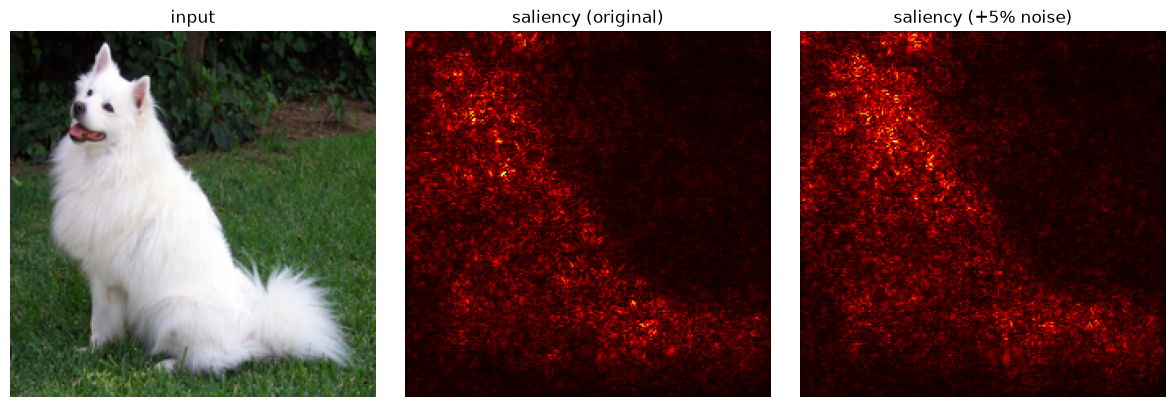

In [2]:
import io
import urllib.request
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval()
categories = weights.meta["categories"]
preprocess = weights.transforms()
url = "https://github.com/pytorch/hub/raw/master/images/dog.jpg"
img = Image.open(io.BytesIO(urllib.request.urlopen(url).read())).convert("RGB")
x = preprocess(img).unsqueeze(0)


def saliency_map(inp):
    inp = inp.clone().requires_grad_(True)
    score = model(inp)
    cls = score.argmax(1).item()
    model.zero_grad()
    score[0, cls].backward()
    return inp.grad.abs().amax(dim=1)[0].numpy(), cls


sal_orig, cls_orig = saliency_map(x)

# Add tiny Gaussian noise: imperceptible and too small to change the prediction.
torch.manual_seed(0)
x_noisy = x + 0.05 * torch.randn_like(x)
sal_noisy, cls_noisy = saliency_map(x_noisy)

corr = np.corrcoef(sal_orig.ravel(), sal_noisy.ravel())[0, 1]
print(f"Prediction:   original = {categories[cls_orig]},  "
      f"noised = {categories[cls_noisy]}  (unchanged)")
print(f"Correlation between the two saliency maps: {corr:.3f}  (1.0 would be identical)")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img.resize((224, 224))); ax[0].axis("off"); ax[0].set_title("input")
ax[1].imshow(sal_orig, cmap="hot"); ax[1].axis("off"); ax[1].set_title("saliency (original)")
ax[2].imshow(sal_noisy, cmap="hot"); ax[2].axis("off"); ax[2].set_title("saliency (+5% noise)")
plt.tight_layout()
plt.show()

The two images are indistinguishable to the eye and receive the identical label, yet their saliency maps are visibly different and only moderately correlated. If a tiny, meaningless perturbation reshuffles the explanation, then any single saliency map should be read with caution: its fine details are partly an artifact of the exact input rather than a stable statement about the model. This instability is why averaging methods such as SmoothGrad, which blur many noisy saliency maps together, are often used in practice, and it is a reason to trust the coarse agreement of Grad-CAM more than the precise speckle of a raw gradient.

## Correlated Features Confound Importance

The permutation importance from Section 12.2 has a specific, important weakness that we flagged then and demonstrate now. When two features carry the same information, permuting either one alone does less harm than it should, because the model recovers much of the signal from its untouched twin. Each feature then looks less important than the information the pair jointly carries, and that shared, decisive contribution stays hidden unless the features are examined together.

We construct the trap deliberately. Feature `A` genuinely drives the target. Feature `B` is a near-perfect copy of `A`. Feature `C` is pure noise. A little weight decay encourages the network to spread its reliance across the redundant pair. We then compute permutation importance for each feature individually, and also for `A` and `B` shuffled *together*.

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

N = 2000
A = np.random.randn(N)
B = A + 0.01 * np.random.randn(N)          # B is nearly identical to A
C = np.random.randn(N)                      # pure noise
y = (A + 0.3 * np.random.randn(N) > 0).astype(np.float32)   # target depends on A
X = torch.tensor(np.stack([A, B, C], axis=1), dtype=torch.float32)
yt = torch.tensor(y).unsqueeze(1)
names = ["A (informative)", "B (copy of A)", "C (noise)"]

model = nn.Sequential(nn.Linear(3, 32), nn.ReLU(), nn.Linear(32, 1))
opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-2)
loss_fn = nn.BCEWithLogitsLoss()
for _ in range(400):
    opt.zero_grad()
    loss_fn(model(X), yt).backward()
    opt.step()


def accuracy(data):
    with torch.no_grad():
        return ((torch.sigmoid(model(data)) >= 0.5).float() == yt).float().mean().item()


base = accuracy(X)


def perm_importance(cols, n_repeats=30):
    drops = []
    for _ in range(n_repeats):
        Xp = X.clone()
        perm = torch.randperm(N)
        for j in cols:
            Xp[:, j] = X[perm, j]          # shuffle listed columns together
        drops.append(base - accuracy(Xp))
    return float(np.mean(drops))


individual = [perm_importance([j]) for j in range(3)]
joint_AB = perm_importance([0, 1])

print(f"corr(A, B) = {np.corrcoef(A, B)[0, 1]:.3f}    baseline accuracy = {base:.3f}\n")
for name, imp in zip(names, individual):
    print(f"  shuffle {name:16s} -> importance {imp:+.4f}")
print(f"  shuffle A and B TOGETHER    -> importance {joint_AB:+.4f}")

corr(A, B) = 1.000    baseline accuracy = 0.910

  shuffle A (informative)  -> importance +0.1717
  shuffle B (copy of A)    -> importance +0.1719
  shuffle C (noise)        -> importance -0.0008
  shuffle A and B TOGETHER    -> importance +0.4119


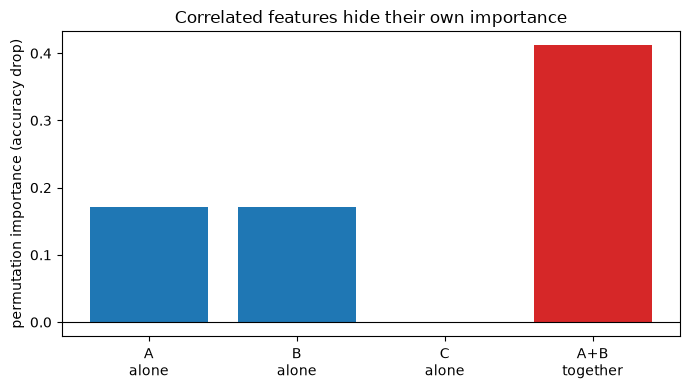

In [4]:
labels = ["A\nalone", "B\nalone", "C\nalone", "A+B\ntogether"]
values = individual + [joint_AB]
colors = ["tab:blue", "tab:blue", "tab:gray", "tab:red"]

plt.figure(figsize=(7, 4))
plt.bar(labels, values, color=colors)
plt.ylabel("permutation importance (accuracy drop)")
plt.title("Correlated features hide their own importance")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

The result exposes the trap. Shuffled on their own, `A` and `B` each register only moderate importance, because whenever one is scrambled the model recovers most of the signal from its untouched twin. Yet permuting the two *together* produces a drop far larger than either alone, and larger even than their sum, revealing that the shared information is far more important than any individual score admits. A practitioner ranking features by their individual importance would badly underrate this signal, filing `A` and `B` among the middling features when together they are the most decisive input in the data, while the genuinely useless feature `C` correctly sits at zero. Correlation among features is common in real data, which makes this failure mode a practical hazard, not a contrived one.

## Using Explanations Responsibly

None of this means explanation methods are useless; it means they are instruments with known error characteristics, to be read critically rather than literally. A few habits keep them honest.

* **Corroborate across methods.** Trust a conclusion more when independent techniques agree, as occlusion, saliency, and Grad-CAM did on the dog, or as permutation importance and the linear model's weights did on the tumor data. A finding that only one method supports deserves skepticism.
* **Test for stability.** Perturb the input, reshuffle random seeds, or vary the held-out sample, and see whether the explanation holds. An explanation that changes under trivial variation is telling you about noise, not about the model.
* **Account for correlation.** Before reading feature importances, check how correlated the features are. Group related features and consider their joint importance rather than judging each in isolation.
* **Remember that plausibility is not proof.** A heatmap that lands where you expected confirms your expectation, not the model's correctness; explanations are vulnerable to confirmation bias, and can even be adversarially manipulated to look reasonable while hiding what the model truly does.

Explainability is an indispensable part of building models that people can rely on, but it is a lens, not a window. Held to that standard, the techniques in this module, interpretable models, feature importance, and the visual and gradient-based methods for vision, give real and actionable insight into otherwise opaque networks. Used uncritically, they offer false comfort. The difference lies not in the tools but in the care with which they are read.